In [5]:
import pandas as pd
import scanpy as sc
import anndata as ad

# Load the CSV data into a pandas DataFrame
df = pd.read_csv("/Users/olsen/Desktop/MMProject/IMCData/MMData_clustering.csv")

/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_36787/2796554066.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/olsen/Desktop/MMProject/IMCData/MMData_clustering.csv")


In [6]:
# Convert the DataFrame to AnnData, assuming columns are markers and rows are cells
adata = sc.AnnData(df)
metadata = df[['Diagnosis', 'Slide_ID']]

# Subsets df from CD45 to CD16
marker_columns = df.loc[:, 'CD45':'CD16']  # Select columns from CD45 to CD16

# Exclude CD28 and CD223_LAG3
excluded_markers = ['CD28', 'CD223_LAG3']
marker_columns = marker_columns.drop(columns=[col for col in excluded_markers if col in marker_columns.columns])

# Convert the marker data to AnnData for clustering
adata = sc.AnnData(marker_columns.values, obs=metadata, var=pd.DataFrame(index=marker_columns.columns))
#sc.pp.scale(adata)


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/anndata/utils.py:304: UserWarning: X converted to numpy array with dtype object
  warnings.warn(f"{name} converted to numpy array with dtype {arr.dtype}")
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [8]:
# PCA starting w/ 5 PC's
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=5)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=5, random_state=0)
sc.tl.leiden(adata)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_36787/1330695143.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


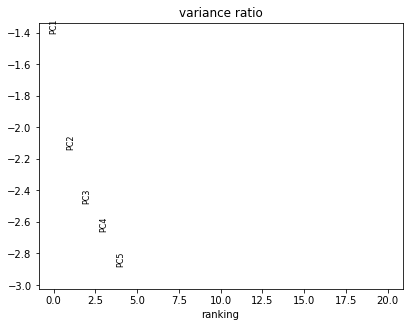

In [9]:
# Plot the amount of variance explained by each PC
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=20)

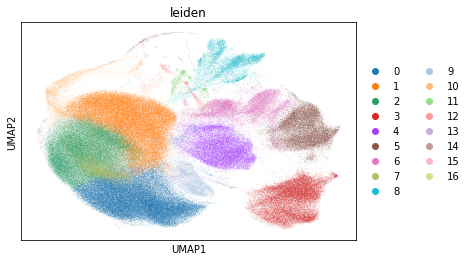

In [10]:
# Leiden clustering w/ PCA
sc.tl.leiden(adata, resolution=0.5)  # Adjust resolution if needed

# UMAP
sc.tl.umap(adata)
sc.pl.umap(adata, color='leiden')

In [3]:
# Perform clustering of all cells (no PCA)
sc.pp.neighbors(adata, n_neighbors=10, random_state=0)
sc.tl.leiden(adata, resolution=0.5, random_state=0)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_63244/2126347025.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5, random_state=0)


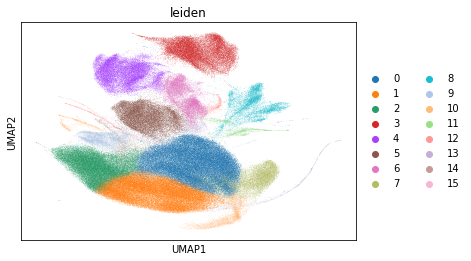

In [4]:
# UMAP projection of all cells in the sample
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden")

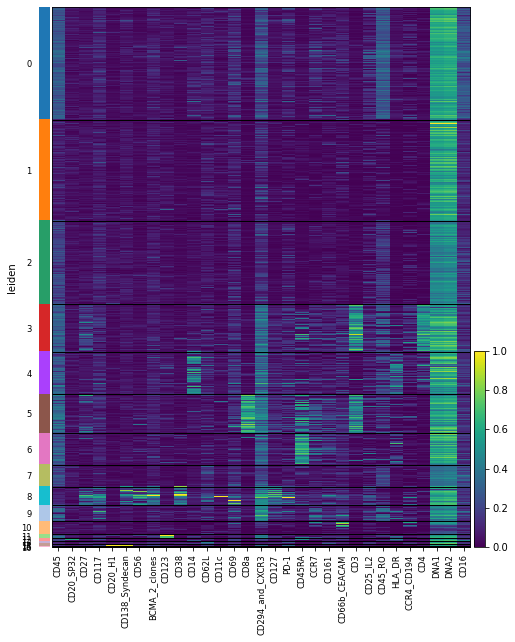

In [12]:
# Create heatmap grouped by all Leiden clusters
marker_list = adata.var_names.tolist()

# Plot heatmap
sc.pl.heatmap(
    adata,
    var_names=marker_list,          
    groupby='leiden',                
    standard_scale='var',
    figsize=(8, 10),
    cmap='viridis',               
    show=True
)

In [59]:
# Clustering of cluster 8 (MM) cells
cluster8 = adata[adata.obs['leiden'] == '8'].copy()

sc.pp.neighbors(cluster8, n_neighbors=10, random_state=0)
sc.tl.leiden(cluster8, resolution=0.245, random_state=0)

In [13]:
# Clustering of cluster 8 (MM) cells w/ PCA
cluster8 = adata[adata.obs['leiden'] == '8'].copy()

# Scale and run PCA on 25 components
sc.pp.scale(cluster8, max_value=10)
sc.tl.pca(cluster8, n_comps=25)

# Compute neighbors using those 25 PCs
sc.pp.neighbors(cluster8, n_neighbors=10, n_pcs=25, random_state=0)

# Run Leiden clustering
sc.tl.leiden(cluster8, resolution=0.245, random_state=0)


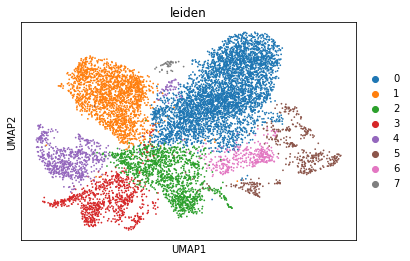

In [14]:
sc.tl.umap(cluster8)
sc.pl.umap(cluster8, color="leiden")

In [61]:
from scipy.sparse import issparse  
# Save UMAP coordinates and metadata
umap_df = cluster8.obs.copy()  # Copy metadata
umap_df[['UMAP1', 'UMAP2']] = cluster8.obsm['X_umap']  # Add UMAP coordinates
umap_df.to_csv('MM_cells_umap.csv')

/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_63244/3402463649.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = obs_df.groupby(['Diagnosis', 'Slide_ID', 'cluster']).size().reset_index(name='Count')
/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_63244/3402463649.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = counts.groupby(['Diagnosis', 'cluster'])['per 100k'].sum().reset_index()
/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_63244/3402463649.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futur

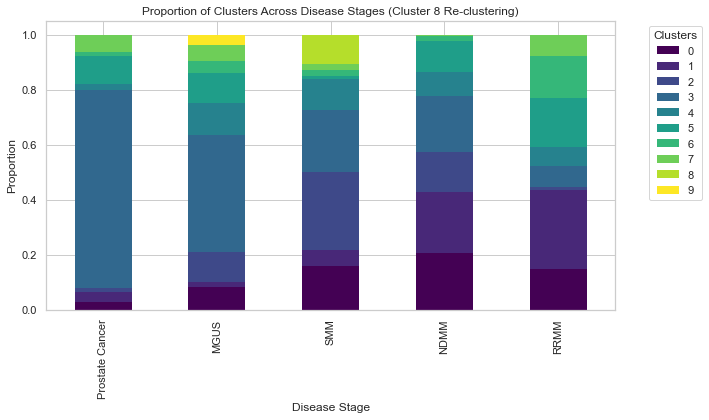

In [47]:
# proportion of clusters across disease stages, normalized per 100k

import pandas as pd
import matplotlib.pyplot as plt

# Extract metadata
obs_df = cluster8.obs.copy()

# Ensure Slide_ID is uniform
obs_df["Slide_ID"] = obs_df["Slide_ID"].astype(str).str.zfill(6)

# Rename 'leiden' to 'cluster' for consistency with your plotting code
obs_df = obs_df.rename(columns={'leiden': 'cluster'})

# Step 1: Count cells per Slide_ID, cluster, and Disease Stage
counts = obs_df.groupby(['Diagnosis', 'Slide_ID', 'cluster']).size().reset_index(name='Count')

# Step 2: Total cells per Slide_ID
total_cells = obs_df.groupby('Slide_ID').size().reset_index(name='Total_Cells')

# Step 3: Merge and calculate per 100k
counts = counts.merge(total_cells, on='Slide_ID')
counts['per 100k'] = (counts['Count'] / counts['Total_Cells']) * 100000

# Step 4: Aggregate across Slide_IDs by Disease Stage and cluster
grouped = counts.groupby(['Diagnosis', 'cluster'])['per 100k'].sum().reset_index()

# Step 5: Calculate proportions (within each disease stage)
grouped['total'] = grouped.groupby('Diagnosis')['per 100k'].transform('sum')
grouped['proportion'] = grouped['per 100k'] / grouped['total']

# Step 6: Reorder Disease Stage
order = ['Prostate Cancer', 'MGUS', 'SMM', 'NDMM', 'RRMM']
grouped['Diagnosis'] = pd.Categorical(grouped['Diagnosis'], categories=order, ordered=True)

# Step 7: Pivot for plotting
pivot_table = grouped.pivot(index='Diagnosis', columns='cluster', values='proportion').fillna(0)
pivot_table = pivot_table.loc[order]

# Step 8: Plot
pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', edgecolor='none')

plt.title('Proportion of Clusters Across Disease Stages (Cluster 8 Re-clustering)')
plt.ylabel('Proportion')
plt.xlabel('Disease Stage')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [49]:
# leiden clustering of stroma
stroma = adata[adata.obs['leiden'] != '8'].copy()

sc.pp.neighbors(stroma, n_neighbors=30, random_state=0)
sc.tl.leiden(stroma, resolution=0.25, random_state=0)

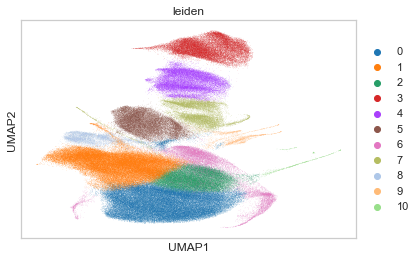

In [50]:
sc.tl.umap(stroma)
sc.pl.umap(stroma, color="leiden")

In [56]:
from scipy.sparse import issparse  
# Save UMAP coordinates and metadata
umap_df = stroma.obs.copy()  # Copy metadata
umap_df[['UMAP1', 'UMAP2']] = stroma.obsm['X_umap']  # Add UMAP coordinates
umap_df.to_csv('stroma_cells_umap.csv')

In [16]:
# Create heatmap grouped by all Leiden clusters
marker_list = adata.var_names.tolist()

# Plot heatmap
sc.pl.heatmap(
    stroma,
    var_names=marker_list,          
    groupby='leiden',                
    standard_scale='var',
    figsize=(8, 10),
    cmap='viridis',               
    show=True
)

NameError: name 'stroma' is not defined

/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_63244/1758763015.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = obs_df.groupby(['Diagnosis', 'Slide_ID', 'cluster']).size().reset_index(name='Count')
/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_63244/1758763015.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = counts.groupby(['Diagnosis', 'cluster'])['per 100k'].sum().reset_index()
/var/folders/s4/06b809wn5yj090rj5zkww0qm0000gn/T/ipykernel_63244/1758763015.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futur

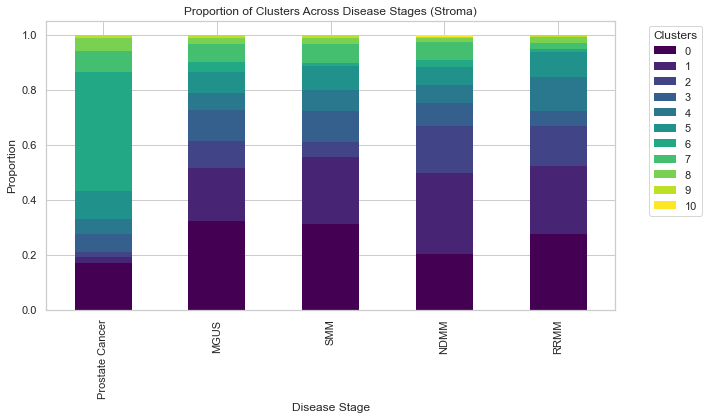

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract metadata
obs_df = stroma.obs.copy()

# Ensure Slide_ID is uniform
obs_df["Slide_ID"] = obs_df["Slide_ID"].astype(str).str.zfill(6)

# Rename 'leiden' to 'cluster' for consistency with your plotting code
obs_df = obs_df.rename(columns={'leiden': 'cluster'})

# Step 1: Count cells per Slide_ID, cluster, and Disease Stage
counts = obs_df.groupby(['Diagnosis', 'Slide_ID', 'cluster']).size().reset_index(name='Count')

# Step 2: Total cells per Slide_ID
total_cells = obs_df.groupby('Slide_ID').size().reset_index(name='Total_Cells')

# Step 3: Merge and calculate per 100k
counts = counts.merge(total_cells, on='Slide_ID')
counts['per 100k'] = (counts['Count'] / counts['Total_Cells']) * 100000

# Step 4: Aggregate across Slide_IDs by Disease Stage and cluster
grouped = counts.groupby(['Diagnosis', 'cluster'])['per 100k'].sum().reset_index()

# Step 5: Calculate proportions (within each disease stage)
grouped['total'] = grouped.groupby('Diagnosis')['per 100k'].transform('sum')
grouped['proportion'] = grouped['per 100k'] / grouped['total']

# Step 6: Reorder Disease Stage
order = ['Prostate Cancer', 'MGUS', 'SMM', 'NDMM', 'RRMM']
grouped['Diagnosis'] = pd.Categorical(grouped['Diagnosis'], categories=order, ordered=True)

# Step 7: Pivot for plotting
pivot_table = grouped.pivot(index='Diagnosis', columns='cluster', values='proportion').fillna(0)
pivot_table = pivot_table.loc[order]

# Step 8: Plot
pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', edgecolor='none')

plt.title('Proportion of Clusters Across Disease Stages (Stroma)')
plt.ylabel('Proportion')
plt.xlabel('Disease Stage')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


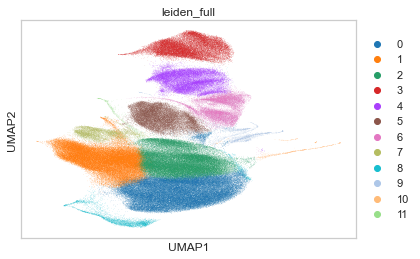

Removing CD20_SP32...
ARI without CD20_SP32: 0.1682
Removing CD20_H1...
ARI without CD20_H1: 0.1362
Removing CD69...
ARI without CD69: 0.1590
Removing CD66b_CEACAM...
ARI without CD66b_CEACAM: 0.1220
Removing CD4...
ARI without CD4: 0.0757
Removing CD56...
ARI without CD56: 0.1500

Adjusted Rand Index per marker removed:
                   ARI
CD20_SP32     0.168245
CD69          0.159044
CD56          0.150004
CD20_H1       0.136177
CD66b_CEACAM  0.121979
CD4           0.075655


In [62]:
# adjusted rand index
import scanpy as sc
import pandas as pd
from sklearn.metrics import adjusted_rand_score
import numpy as np
import random
import time

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Define markers to test
markers_of_interest = ["CD20_SP32", "CD20_H1", "CD69", "CD66b_CEACAM", "CD4", "CD56"]

# Subset: stroma cells only
cluster_env = adata[adata.obs['leiden'] != '8'].copy()

# Baseline clustering on all markers
sc.pp.neighbors(cluster_env, n_neighbors=30, random_state=42)
sc.tl.leiden(cluster_env, resolution=0.25, key_added="leiden_full", random_state=0)

# Store original labels
cluster_env.obs["leiden_original"] = cluster_env.obs["leiden_full"]

# UMAP for visualization (optional)
sc.tl.umap(cluster_env, random_state=0)
sc.pl.umap(cluster_env, color="leiden_full")

# To store ARI values
ari_scores = {}

# Loop: drop one marker at a time
for marker in markers_of_interest:
    print(f"Removing {marker}...")

    # Markers minus the one being removed
    subset_markers = [m for m in markers_of_interest if m != marker]

    # Subset the AnnData object to those markers only
    adata_temp = cluster_env[:, subset_markers].copy()

    # Clustering
    sc.pp.neighbors(adata_temp, n_neighbors=30, random_state=42)
    sc.tl.leiden(adata_temp, resolution=0.25, key_added="leiden_temp", random_state=42)

    # Compute Adjusted Rand Index vs baseline
    ari = adjusted_rand_score(cluster_env.obs["leiden_original"], adata_temp.obs["leiden_temp"])
    ari_scores[marker] = ari
    print(f"ARI without {marker}: {ari:.4f}")

# View results
ari_df = pd.DataFrame.from_dict(ari_scores, orient='index', columns=['ARI']).sort_values("ARI", ascending=False)
print("\nAdjusted Rand Index per marker removed:")
print(ari_df)

# Optionally: Save to CSV
ari_df.to_csv("ari_stroma_marker_removal.csv")